In [5]:
import os 
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [6]:
img = cv2.imread("Luffy.jpg")
print(type(img))
print(img.shape)
print(img.size)

<class 'numpy.ndarray'>
(1278, 1190, 3)
4562460


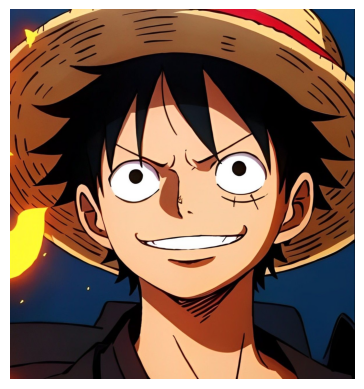

In [7]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

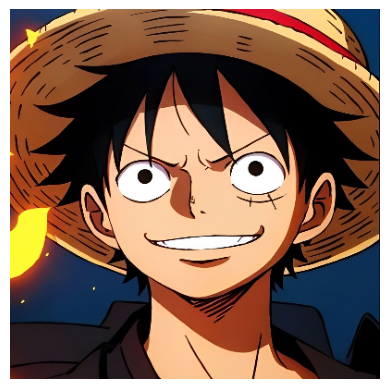

In [9]:
img_resized = cv2.resize(img, (400, 400))
plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

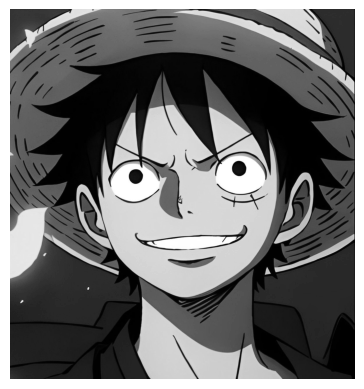

In [10]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()

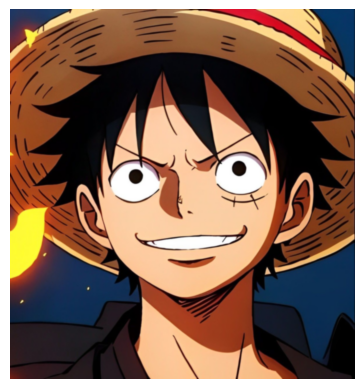

In [11]:
img_blur = cv2.GaussianBlur(img, (7, 7), 0)
plt.imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

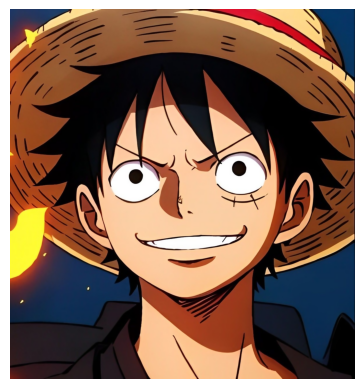

In [12]:
img_bilateral = cv2.bilateralFilter(img, d=7, sigmaColor=45, sigmaSpace=45)
plt.imshow(cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

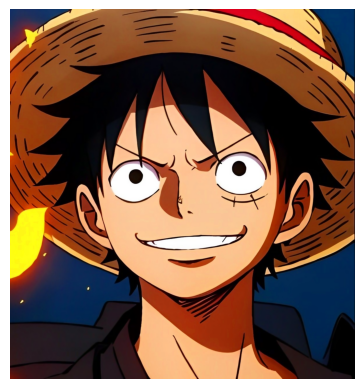

In [13]:
img_hsv = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2HSV).astype(np.float32)
img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * 1.15, 0, 255)
img_saturated = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

plt.imshow(cv2.cvtColor(img_saturated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

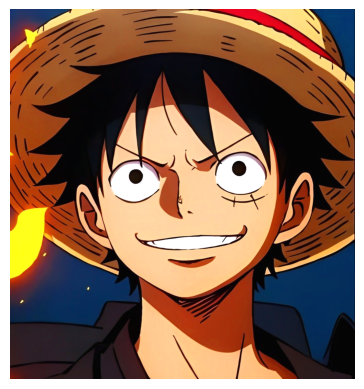

In [14]:
img_contrast = cv2.convertScaleAbs(img_saturated, alpha=1.05, beta=4)
plt.imshow(cv2.cvtColor(img_contrast, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

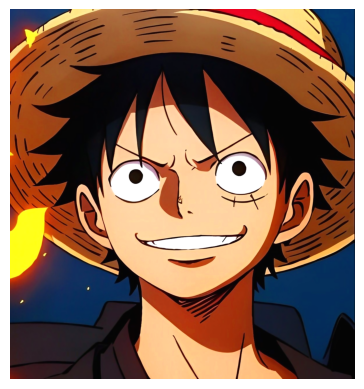

In [15]:
img_soft = cv2.GaussianBlur(img_contrast, (0, 0), sigmaX=1.2)
img_sharpened = cv2.addWeighted(img_contrast, 1.12, img_soft, -0.12, 0)

plt.imshow(cv2.cvtColor(img_sharpened, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

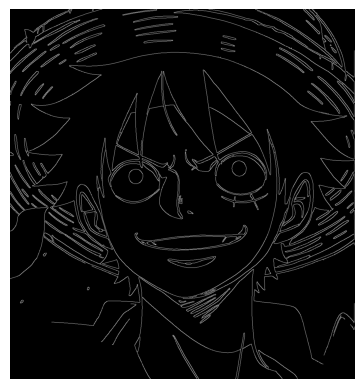

In [16]:
img_edges = cv2.Canny(img_gray, 80, 160)
plt.imshow(img_edges, cmap="gray")
plt.axis("off")
plt.show()

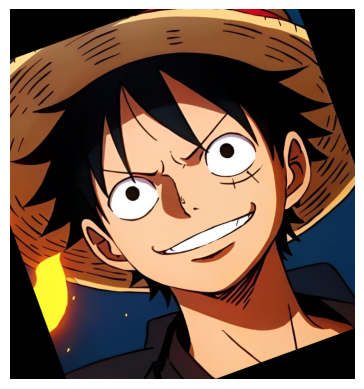

In [17]:
h, w = img.shape[:2]
rot_matrix = cv2.getRotationMatrix2D((w // 2, h // 2), 20, 1.0)
img_rotated = cv2.warpAffine(img, rot_matrix, (w, h))

plt.imshow(cv2.cvtColor(img_rotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

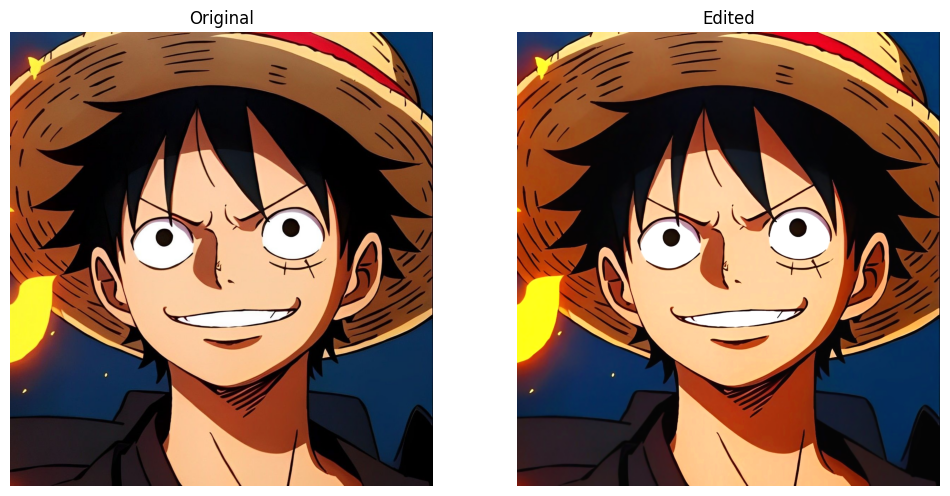

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_sharpened, cv2.COLOR_BGR2RGB))
axes[1].set_title("Edited")
axes[1].axis("off")

plt.show()